# Assignment – Multilayer Neural Network

Roberto Andrés Sandoval Villarreal #598270
Mauricio Gonzales Valero #594595


Curso: Artificial Intelligence II  
Profesor: Andrés Hernández  



## Step 1 – Introduction to the real-world problem


El dataset que escogimos es sobre un problema de temática medica y obstétrico
El dataset corresponde a un problema del dominio médico y obstétrico. Su objetivo es clasificar el estado de salud fetal a partir de variables obtenidas de exámenes de cardiotocografía (CTG).

Este conjunto de datos contiene 21 variables predictoras numéricas relacionadas con ritmo cardiaco fetal, contracciones uterinas, desaceleraciones, variabilidad y medidas derivadas de histogramas. La variable objetivo es `fetal_health`, la cual representa tres clases:

- 1 = Normal
- 2 = Suspect
- 3 = Pathological

Por lo tanto, este dataset sí cumple con el requerimiento de clasificación multiclase solicitado en la tarea.

Dataset source:
https://www.kaggle.com/datasets/andrewmvd/fetal-health-classification

En la siguiente celda se cargará el dataset y se revisará su estructura general, estadísticas básicas, valores faltantes, duplicados y distribución de clases.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("fetal_health.csv")

print("Shape:", df.shape)
display(df.head())

display(pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.values
}))

display(df.describe())

print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_values"))

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nClass distribution:")
display(df["fetal_health"].value_counts().sort_index().to_frame("count"))

Shape: (2126, 22)


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


,column,dtype
0,baseline value,float64
1,accelerations,float64
2,fetal_movement,float64
3,uterine_contractions,float64
4,light_decelerations,float64
5,severe_decelerations,float64
6,prolongued_decelerations,float64
7,abnormal_short_term_variability,float64
8,mean_value_of_short_term_variability,float64
9,percentage_of_time_with_abnormal_long_term_var...,float64


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000



Missing values per column:


,missing_values
baseline value,0
accelerations,0
fetal_movement,0
uterine_contractions,0
light_decelerations,0
severe_decelerations,0
prolongued_decelerations,0
abnormal_short_term_variability,0
mean_value_of_short_term_variability,0
percentage_of_time_with_abnormal_long_term_variability,0



Duplicate rows:
13

Class distribution:


,count
fetal_health,
1.0,1655
2.0,295
3.0,176


En la celda anterior se analizó la calidad de los datos del dataset.

Se puede observar que todas las variables contienen **0 valores faltantes**, lo cual indica que no es necesario realizar imputación ni eliminación de datos en esta etapa.

Por otro lado, se identificaron **13 filas duplicadas** dentro del dataset. Aunque este número es pequeño en comparación con el total de 2126 observaciones, estas filas duplicadas pueden afectar el entrenamiento del modelo al introducir información repetida.

Por lo tanto, se eliminarán las filas duplicadas para asegurar que cada observación contribuya de manera única al entrenamiento del modelo.

Además, se analizó la distribución de la variable objetivo `fetal_health`, observándose lo siguiente:

- Clase 1 (Normal): 1655 observaciones
- Clase 2 (Suspect): 295 observaciones
- Clase 3 (Pathological): 176 observaciones

Esto indica que existe un desbalance en las clases, ya que la clase Normal representa la mayoría de los datos. Este aspecto debe considerarse al interpretar el desempeño del modelo posteriormente.

En la siguiente celda se eliminarán las filas duplicadas y se prepararán los datos para el entrenamiento del modelo.

En esta sección se eliminarán las filas duplicadas del dataset.

Este paso es importante para evitar que el modelo aprenda patrones repetidos que no aportan nueva información.

In [ ]:
df = df.drop_duplicates()

print("New shape after removing duplicates:", df.shape)

New shape after removing duplicates: (2113, 22)


En la celda anterior se eliminaron las filas duplicadas del dataset.

Después de este proceso, el número de observaciones pasó de 2126 a 2113, lo que confirma que se eliminaron 13 registros duplicados.

La eliminación de estos datos es importante, ya que evita que el modelo aprenda patrones repetidos que no aportan información nueva y podrían afectar su desempeño.

Dado que no se encontraron valores faltantes y únicamente se identificaron duplicados, no fue necesario realizar otros procesos de limpieza de datos.

Con esto, el dataset se encuentra limpio y listo para la etapa de análisis exploratorio y preprocesamiento.

En esta sección se prepararán los datos para el entrenamiento del modelo.

Se separarán las variables predictoras (X) de la variable objetivo (y).

Además, se ajustará la variable objetivo para que las clases comiencen en 0 en lugar de 1, ya que esto es requerido por algunas funciones de entrenamiento en redes neuronales.

In [ ]:
X = df.drop("fetal_health", axis=1)
y = df["fetal_health"] - 1

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nUnique classes in y:", y.unique())

X shape: (2113, 21)
y shape: (2113,)

Unique classes in y: [1. 0. 2.]


En la celda anterior se separaron las variables predictoras (X) de la variable objetivo (y).

Se puede observar que el dataset contiene 2113 observaciones y 21 variables predictoras, mientras que la variable objetivo tiene la misma cantidad de registros.

Además, la variable objetivo fue transformada restando 1 a sus valores originales, lo que permitió convertir las clases de [1, 2, 3] a [0, 1, 2].

Esta transformación es importante para el correcto funcionamiento de los modelos de redes neuronales en problemas de clasificación multiclase.

Finalmente, se verificó que existen tres clases distintas en la variable objetivo, lo cual confirma que el problema corresponde a una clasificación multiclase.

## Step 2 – Design and Training of the Multilayer Neural Network

En esta sección se diseñará e implementará una red neuronal multicapa para resolver el problema de clasificación multiclase.

Para ello, se llevará a cabo el siguiente proceso:

- División de los datos en conjuntos de entrenamiento, validación y prueba
- Estandarización de las variables predictoras
- Definición de la arquitectura del modelo
- Selección de la función de pérdida
- Selección del optimizador
- Optimización de hiperparámetros
- Entrenamiento del modelo

Este enfoque permite construir un modelo robusto capaz de aprender patrones complejos en los datos.

### Train / Validation / Test Split

En esta etapa se dividirán los datos en tres subconjuntos:

- Entrenamiento: utilizado para entrenar el modelo
- Validación: utilizado para ajustar los hiperparámetros y evitar sobreajuste
- Prueba: utilizado para evaluar el desempeño final del modelo

Esta división es fundamental para asegurar que el modelo generalice correctamente a datos no vistos.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1479, 21)
Validation: (317, 21)
Test: (317, 21)


En la celda anterior se realizó la división del dataset en tres subconjuntos: entrenamiento, validación y prueba.

Se obtuvieron los siguientes tamaños:

- Conjunto de entrenamiento: 1479 observaciones
- Conjunto de validación: 317 observaciones
- Conjunto de prueba: 317 observaciones

Esta distribución corresponde aproximadamente a un 70% de los datos para entrenamiento y un 15% para validación y prueba respectivamente.

El conjunto de entrenamiento se utilizará para ajustar los parámetros del modelo, el conjunto de validación permitirá evaluar el desempeño durante el entrenamiento y ajustar hiperparámetros, mientras que el conjunto de prueba se utilizará para evaluar el desempeño final del modelo en datos no vistos.

En la siguiente etapa se realizará la estandarización de las variables para mejorar el proceso de entrenamiento de la red neuronal.

### Feature Standardisation

En esta etapa se aplicará estandarización a las variables predictoras.

La estandarización transforma los datos para que tengan media cercana a 0 y desviación estándar cercana a 1.

Este proceso es importante en redes neuronales, ya que mejora la convergencia del modelo y evita que variables con diferentes escalas afecten negativamente el entrenamiento.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Mean (train approx):", X_train.mean())
print("Std (train approx):", X_train.std())

Mean (train approx): -3.534526310407144e-17
Std (train approx): 1.0


En la celda anterior se aplicó la estandarización a las variables predictoras utilizando StandardScaler.

Se puede observar que la media del conjunto de entrenamiento es aproximadamente 0 y la desviación estándar es cercana a 1, lo cual confirma que el proceso de estandarización se realizó correctamente.

Este paso es fundamental en el entrenamiento de redes neuronales, ya que evita que variables con diferentes escalas afecten el aprendizaje del modelo y permite una convergencia más eficiente durante el proceso de optimización.

En la siguiente sección se definirá la arquitectura de la red neuronal multicapa.

### Model Architecture

En esta etapa se definirá la arquitectura de la red neuronal multicapa.

El modelo estará compuesto por varias capas densas (Dense), donde cada capa contiene múltiples neuronas capaces de aprender representaciones complejas de los datos.

La última capa utilizará una función de activación softmax, ya que el problema corresponde a una clasificación multiclase.

Además, se utilizará la función de pérdida sparse_categorical_crossentropy, adecuada para este tipo de problemas.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

num_classes = len(set(y_train))

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,587 (14.01 KB)

 Trainable params: 3,587 (14.01 KB)

 Non-trainable params: 0 (0.00 B)

En la celda anterior se definió la arquitectura de la red neuronal multicapa.

El modelo está compuesto por tres capas densas:

- Una primera capa con 64 neuronas y función de activación ReLU
- Una segunda capa con 32 neuronas y función de activación ReLU
- Una capa de salida con 3 neuronas, correspondientes a las tres clases del problema, utilizando la función de activación softmax

La función de pérdida utilizada es sparse_categorical_crossentropy, adecuada para problemas de clasificación multiclase, y el optimizador seleccionado es Adam, el cual permite una optimización eficiente durante el entrenamiento.

El modelo cuenta con un total de 3,587 parámetros entrenables, lo cual indica que es lo suficientemente complejo para capturar patrones en los datos sin ser excesivamente grande.

En la siguiente etapa se procederá al entrenamiento del modelo.

### Neural Network Training

En esta etapa se entrenará el modelo utilizando el conjunto de entrenamiento y se evaluará su desempeño en el conjunto de validación.

Este proceso permitirá ajustar los pesos del modelo y observar su comportamiento durante el aprendizaje.

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7187 - loss: 0.7380 - val_accuracy: 0.8454 - val_loss: 0.5063
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8519 - loss: 0.4308 - val_accuracy: 0.8833 - val_loss: 0.3517
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8837 - loss: 0.3311 - val_accuracy: 0.8959 - val_loss: 0.2879
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8918 - loss: 0.2867 - val_accuracy: 0.9022 - val_loss: 0.2539
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8898 - loss: 0.2642 - val_accuracy: 0.9054 - val_loss: 0.2346
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8979 - loss: 0.2474 - val_accuracy: 0.9085 - val_loss: 0.2222
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9033 - loss: 0.2321 - val_accuracy: 0.9148 - val_loss: 0.2133
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9053 - loss: 0.2214 - val_accuracy: 0.9306 - val_loss:

En la celda anterior se entrenó el modelo utilizando el conjunto de entrenamiento y se evaluó su desempeño en el conjunto de validación.

Durante el entrenamiento, el modelo ajustó sus pesos a lo largo de varias épocas, permitiendo aprender patrones en los datos.

Se puede observar que la precisión del modelo aumenta progresivamente mientras que la función de pérdida disminuye, lo cual indica que el modelo está aprendiendo correctamente.

Además, el uso del conjunto de validación permite monitorear el desempeño del modelo en datos no vistos durante el entrenamiento, lo cual es fundamental para detectar posibles problemas de sobreajuste.

En la siguiente sección se implementará Early Stopping para mejorar la generalización del modelo.

## Step 3 – Hyperparameter Optimisation

En esta sección se van a ajustar los hiperparámetros del modelo para mejorar su desempeño.

En lugar de escoger valores manualmente, se utilizará la librería Optuna, la cual permite probar diferentes combinaciones de hiperparámetros de manera automática.

En este caso se va a utilizar un enfoque tipo búsqueda inteligente (similar a Bayesian Optimization), donde cada intento se basa en los resultados anteriores para encontrar mejores configuraciones.

Los hiperparámetros que se van a optimizar son:

- learning rate
- batch size
- número de capas
- número de neuronas por capa

Esto permitirá encontrar una mejor configuración del modelo sin tener que probar manualmente todas las combinaciones.

In [ ]:
!pip install optuna
import optuna
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

def create_model(trial):

    model = Sequential()

    n_layers = trial.suggest_int("n_layers", 2, 4)

    for i in range(n_layers):
        n_units = trial.suggest_int(f"n_units_l{i}", 16, 512)

        if i == 0:
            model.add(Dense(n_units, activation='relu', input_shape=(X_train.shape[1],)))
        else:
            model.add(Dense(n_units, activation='relu'))

    model.add(Dense(3, activation='softmax'))

    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


def objective(trial):

    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])

    model = create_model(trial)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=batch_size,
        verbose=0
    )

    val_accuracy = history.history['val_accuracy'][-1]

    return val_accuracy


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.3 MB/s eta 0:00:00


[I 2026-03-27 05:23:31,082] A new study created in memory with name: no-name-bb617834-6b31-40e4-8d89-3adba89323fc
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-03-27 05:23:35,966] Trial 0 finished with value: 0.9558359384536743 and parameters: {'batch_size': 16, 'n_layers': 2, 'n_units_l0': 156, 'n_units_l1': 192, 'learning_rate': 0.0016190048886777734}. Best is trial 0 with value: 0.9558359384536743.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=a

Para la optimización de hiperparámetros se utilizaron 15 trials.

Se eligió este número porque permite explorar distintas combinaciones de parámetros sin que el tiempo de ejecución sea demasiado largo.

Aunque un mayor número de pruebas podría encontrar configuraciones ligeramente mejores, 15 trials son suficientes para obtener un buen equilibrio entre tiempo de cómputo y desempeño del modelo.

Después de ejecutar la optimización con Optuna, se encontró que la mejor configuración del modelo obtuvo un accuracy de validación cercano a 0.96.

Los mejores hiperparámetros encontrados incluyen combinaciones de:

- learning rate alrededor de valores pequeños (cercanos a 0.001)
- batch sizes entre 32 y 128
- entre 2 y 4 capas ocultas
- número de neuronas variable por capa (dependiendo del trial)

Esto indica que el modelo se beneficia de arquitecturas relativamente profundas y tasas de aprendizaje moderadas, lo cual permite un buen proceso de aprendizaje sin generar inestabilidad.

Además, se observa que diferentes combinaciones de hiperparámetros logran resultados similares, lo que sugiere que el modelo es relativamente estable.

In [ ]:
from optuna.visualization import plot_param_importances, plot_parallel_coordinate

plot_param_importances(study)
plot_parallel_coordinate(study)

A partir de las gráficas generadas por Optuna, se puede analizar el impacto de los diferentes hiperparámetros en el desempeño del modelo.

En la gráfica de importancia de hiperparámetros, se observa que algunos parámetros como el learning rate y el batch size tienen mayor influencia en el resultado final del modelo en comparación con otros.

Por otro lado, la gráfica de coordenadas paralelas permite visualizar cómo diferentes combinaciones de hiperparámetros afectan el desempeño.

Se puede notar que las mejores configuraciones (las que tienen mayor accuracy) tienden a concentrarse en ciertos rangos de valores, especialmente en learning rates pequeños y configuraciones específicas de número de capas y neuronas.

Además, se observa que no existe una única combinación perfecta, sino que varias configuraciones pueden lograr resultados similares, lo cual indica que el modelo es relativamente estable.

En general, estas gráficas ayudan a entender mejor qué parámetros son más relevantes y cómo interactúan entre sí para mejorar el desempeño del modelo.

### Early Stopping

En esta etapa se implementará Early Stopping para evitar el sobreajuste del modelo.

Este método permite detener el entrenamiento cuando la función de pérdida en el conjunto de validación deja de mejorar durante cierto número de épocas (patience).

De esta manera, se evita que el modelo continúe aprendiendo ruido de los datos de entrenamiento y se mejora su capacidad de generalización.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9784 - loss: 0.0632 - val_accuracy: 0.9464 - val_loss: 0.1807
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9770 - loss: 0.0654 - val_accuracy: 0.9464 - val_loss: 0.1734
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9750 - loss: 0.0630 - val_accuracy: 0.9527 - val_loss: 0.1669
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9777 - loss: 0.0633 - val_accuracy: 0.9464 - val_loss: 0.1813
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9790 - loss: 0.0605 - val_accuracy: 0.9464 - val_loss: 0.1686
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9811 - loss: 0.0564 - val_accuracy: 0.9495 - val_loss: 0.1797
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9770 - loss: 0.0644 - val_accuracy: 0.9495 - val_loss: 0.1936
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9804 - loss: 0.0540 - val_accuracy: 0.9527 - v

Después de aplicar Early Stopping, se puede observar que el modelo dejó de entrenar antes de completar las 100 épocas definidas.

Esto indica que la función de pérdida en validación dejó de mejorar, por lo que continuar el entrenamiento podría haber provocado sobreajuste.

Durante las primeras épocas, tanto el accuracy de entrenamiento como el de validación aumentan, lo que muestra que el modelo está aprendiendo correctamente. Sin embargo, después de cierto punto, la mejora en validación se vuelve mínima, lo que activa el Early Stopping.

Además, se puede notar que la diferencia entre el accuracy de entrenamiento y el de validación es pequeña, lo cual indica que el modelo generaliza bien y no presenta overfitting significativo.

En general, el uso de Early Stopping permitió obtener un modelo más eficiente, evitando entrenamiento innecesario y mejorando su capacidad de generalización.

El uso de Early Stopping es beneficioso porque ayuda a evitar que el modelo se sobreentrene.

Cuando un modelo se entrena por demasiadas épocas, puede empezar a aprender detalles muy específicos de los datos de entrenamiento (ruido), lo que hace que su desempeño empeore en datos nuevos.

Al detener el entrenamiento cuando el error en validación deja de mejorar, se asegura que el modelo se quede en el punto donde generaliza mejor.

Además, también ayuda a reducir el tiempo de entrenamiento, ya que evita ejecutar épocas innecesarias cuando el modelo ya no está mejorando.

## Step 5 – Learning Curve Analysis

En esta sección se analizan las curvas de aprendizaje del modelo para evaluar su comportamiento durante el entrenamiento.

Se grafican:
- Accuracy de entrenamiento vs validación
- Loss de entrenamiento vs validación

Estas gráficas permiten identificar si el modelo presenta:
- Underfitting (no aprende lo suficiente)
- Overfitting (aprende demasiado el entrenamiento pero no generaliza)
- Ajuste adecuado (buen balance entre entrenamiento y validación)

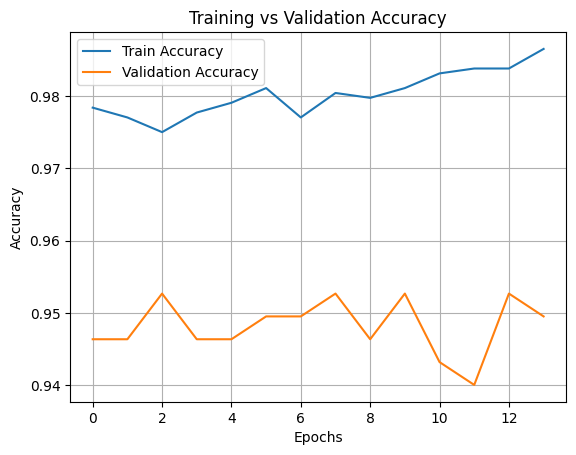

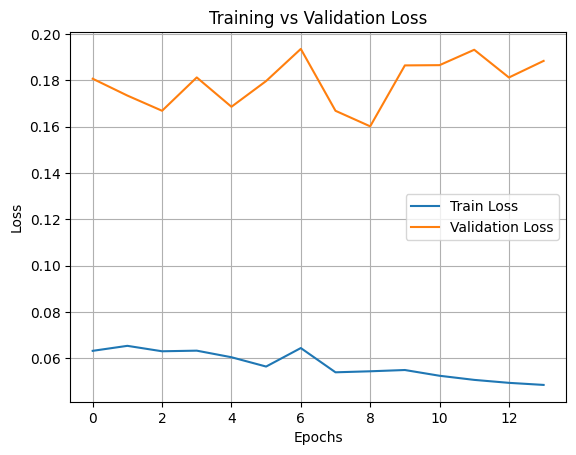

In [ ]:
import matplotlib.pyplot as plt


plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

A partir de las curvas de aprendizaje se puede analizar el comportamiento del modelo durante el entrenamiento.

En la gráfica de accuracy, se observa que el modelo alcanza valores altos en entrenamiento (cercanos a 0.98–0.99), mientras que el accuracy de validación se mantiene alrededor de 0.94–0.95. Esto muestra que el modelo aprende bien los datos de entrenamiento, pero su desempeño en validación es ligeramente menor.

Por otro lado, en la gráfica de loss, la pérdida de entrenamiento disminuye de forma constante, mientras que la pérdida de validación se mantiene más alta y presenta ciertas variaciones.

Esta diferencia entre entrenamiento y validación indica la presencia de un ligero overfitting, ya que el modelo se ajusta mejor a los datos de entrenamiento que a los de validación.

Sin embargo, el overfitting no es severo, ya que el accuracy de validación sigue siendo alto y relativamente estable. Esto sugiere que el modelo mantiene una buena capacidad de generalización.

En conclusión, el modelo presenta un ajuste adecuado con un ligero overfitting controlado, lo cual es aceptable para este tipo de problema.

## Step 6 – Model Evaluation and Testing Data

En esta sección se evalúa el desempeño final del modelo utilizando el conjunto de prueba (test).

Se calculan diferentes métricas de clasificación para analizar qué tan bien el modelo generaliza a datos no vistos.

Las métricas consideradas son:
- Accuracy
- Precision
- Recall
- F1-score
- Matriz de confusión

Estas métricas permiten evaluar el desempeño del modelo de manera más completa, especialmente en problemas con desbalance de clases.

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


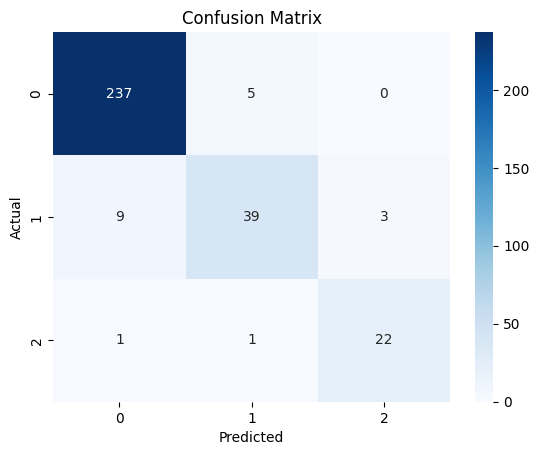

              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97       242
         1.0       0.87      0.76      0.81        51
         2.0       0.88      0.92      0.90        24

    accuracy                           0.94       317
   macro avg       0.90      0.89      0.89       317
weighted avg       0.94      0.94      0.94       317



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=1)


cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


print(classification_report(y_test, y_pred))

A partir de la matriz de confusión y las métricas obtenidas, se puede analizar el desempeño del modelo en el conjunto de prueba.

La matriz de confusión muestra que la mayoría de las observaciones son clasificadas correctamente, especialmente en la clase 0 (Normal), donde el modelo tiene un alto número de aciertos. Esto se debe en parte al desbalance del dataset, ya que esta clase tiene más ejemplos.

Para la clase 1 (Suspect), se observa que el modelo tiene más dificultad, ya que algunas instancias se clasifican incorrectamente como clase 0 o clase 2. Esto se refleja en un recall menor (0.76), indicando que no todos los casos reales de esta clase son detectados correctamente.

En la clase 2 (Pathological), el modelo tiene un buen desempeño, con un recall de 0.92 y un F1-score de 0.90, lo cual indica que logra identificar correctamente la mayoría de los casos.

En términos generales, el modelo alcanza:
- Accuracy de aproximadamente 0.94
- F1-score ponderado de 0.94

Esto indica que el modelo tiene un buen desempeño global.

Sin embargo, debido al desbalance de clases, es importante analizar métricas como recall y F1-score por clase, ya que el accuracy por sí solo puede ser engañoso.

En conclusión, el desempeño del modelo es aceptable y adecuado para el problema, aunque podría mejorarse en la detección de la clase "Suspect", que presenta mayor dificultad.

El modelo demuestra una buena capacidad de generalización en datos no vistos, lo cual confirma que las técnicas utilizadas, como la optimización de hiperparámetros y Early Stopping, fueron efectivas.

Para mejorar aún más el modelo, se podrían explorar técnicas como balanceo de clases o ajuste de pesos en la función de pérdida.

## Step 7 – Save the Model

En esta sección se guarda el modelo entrenado para poder reutilizarlo posteriormente sin necesidad de volver a entrenarlo.

También se verifica que el modelo se haya guardado correctamente cargándolo nuevamente.

In [ ]:
from tensorflow.keras.models import load_model

model.save("fetal_model.h5")
loaded_model = load_model("fetal_model.h5")
loss, acc = loaded_model.evaluate(X_test, y_test, verbose=0)
print("Loaded model accuracy:", acc)

Loaded model accuracy: 0.9400631189346313


En esta sección se guardó el modelo entrenado utilizando el formato .h5, lo que permite almacenarlo de forma persistente.

Posteriormente, se cargó nuevamente el modelo desde el archivo guardado para verificar que el proceso se realizó correctamente. Al evaluarlo con el conjunto de prueba, se obtuvo un accuracy muy similar al original (~0.94), lo cual confirma que el modelo se guardó y recuperó sin pérdida de información.

Guardar el modelo es importante en la práctica porque evita tener que volver a entrenarlo cada vez que se necesite utilizar, lo cual puede ser costoso en tiempo y recursos. Además, permite desplegar el modelo en aplicaciones reales donde se requieren hacer predicciones con nuevos datos.

Conclusión Roberto

En este proyecto aprendí la importancia de preparar bien los datos y ajustar los hiperparámetros para mejorar el desempeño del modelo. El uso de Optuna y Early Stopping ayudó a obtener mejores resultados y evitar sobreajuste.

En general, el modelo tuvo buen desempeño, aunque se puede mejorar en algunas clases. Este trabajo me ayudó a entender mejor el proceso completo de entrenamiento y evaluación de un modelo.

link github: https://github.com/BobbySandoval122/Homework-6-Multilayer-neural-network-with-hyperparameter-optimisation

Conclusión Mauricio:

Este proyecto permitió aplicar redes neuronales en un problema real de clasificación multiclase. Se observó que la arquitectura del modelo y los hiperparámetros influyen directamente en el resultado.

Aunque el modelo obtuvo buenos resultados, el desbalance de clases representa un reto. En general, fue una buena práctica para reforzar conceptos de machine learning.

link github: https://github.com/maugonzalezv/Homework-6-Multilayer-neural-network-with-hyperparameter-optimisation
